In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\gujar\OneDrive\Desktop\AVS CODE\Data_Analyst_Portfoio\Loan_Default_Analysis\data\cleaned_loan_data.csv")

In [3]:
df.shape

(10000, 51)

In [4]:
df.head()

,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,...,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees,loan_default
0,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,0,38.0,2001,6,...,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0,0
1,10.0,HI,RENT,40000.0,Not Verified,5.04,0,-1.0,1996,1,...,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0,0
2,3.0,WI,RENT,40000.0,Source Verified,21.15,0,28.0,2006,4,...,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0,0
3,1.0,PA,RENT,30000.0,Not Verified,10.16,0,-1.0,2007,0,...,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0,0
4,10.0,CA,RENT,35000.0,Verified,57.96,0,-1.0,2008,7,...,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0,0


In [5]:
df.describe()

,emp_length,annual_income,debt_to_income,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,...,loan_amount,term,interest_rate,installment,balance,paid_total,paid_principal,paid_interest,paid_late_fees,loan_default
count,10000.000000,1.000000e+04,10000.000000,10000.00000,10000.000000,10000.00000,10000.00000,10000.000000,10000.00000,1.000000e+04,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.936000,7.922215e+04,19.304020,0.21600,15.395700,2001.29000,1.95820,22.679600,11.40440,1.836062e+05,...,16361.922500,43.272000,12.427524,476.205323,14458.916610,2494.234773,1894.448466,599.666781,0.119516,0.017800
std,3.549248,6.473429e+04,14.987074,0.68366,23.527411,7.79551,2.38013,11.885439,5.86828,1.876327e+05,...,10301.956759,11.029877,5.001105,294.851627,9964.561865,3958.230365,3884.407175,517.328062,1.813468,0.132231
min,0.000000,0.000000e+00,0.000000,0.00000,-1.000000,1963.00000,0.00000,2.000000,0.00000,0.000000e+00,...,1000.000000,36.000000,5.310000,30.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.500000e+04,11.067500,0.00000,-1.000000,1997.00000,0.00000,14.000000,7.00000,5.159375e+04,...,8000.000000,36.000000,9.430000,256.040000,6679.065000,928.700000,587.100000,221.757500,0.000000,0.000000
50%,6.000000,6.500000e+04,17.570000,0.00000,-1.000000,2003.00000,1.00000,21.000000,10.00000,1.146670e+05,...,14500.000000,36.000000,11.980000,398.420000,12379.495000,1563.300000,984.990000,446.140000,0.000000,0.000000
75%,10.000000,9.500000e+04,24.990000,0.00000,29.000000,2006.00000,3.00000,29.000000,14.00000,2.675500e+05,...,24000.000000,60.000000,15.050000,644.690000,20690.182500,2616.005000,1694.555000,825.420000,0.000000,0.000000
max,10.000000,2.300000e+06,469.090000,13.00000,118.000000,2015.00000,29.00000,87.000000,51.00000,3.386034e+06,...,40000.000000,60.000000,30.940000,1566.590000,40000.000000,41630.443684,40000.000000,4216.440000,52.980000,1.000000


In [6]:
df['loan_default'].value_counts()

loan_default
0    9822
1     178
Name: count, dtype: int64

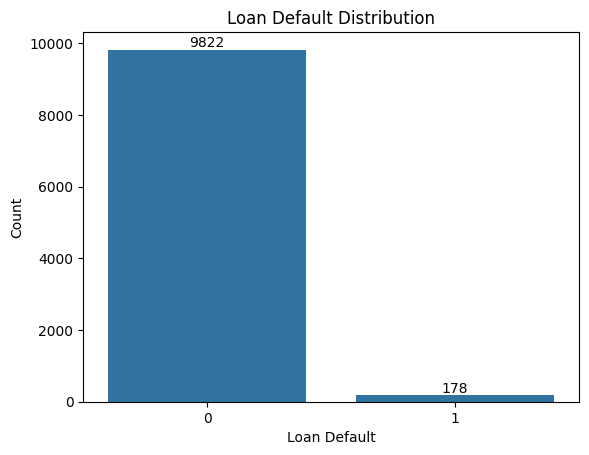

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
ax=sns.countplot(data=df, x='loan_default')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Loan Default Distribution')
plt.xlabel('Loan Default')
plt.ylabel('Count')
plt.show()

In [8]:
df.groupby('loan_default')['interest_rate'].mean()

loan_default
0    12.360975
1    16.099663
Name: interest_rate, dtype: float64

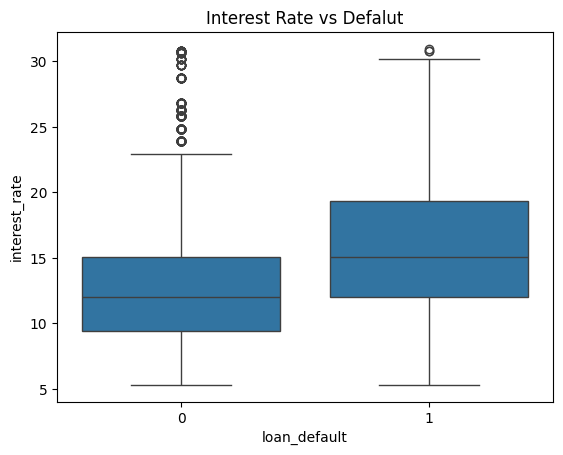

In [9]:
sns.boxplot(
    data=df,
    x='loan_default',
    y='interest_rate'
)
plt.title('Interest Rate vs Defalut')
plt.show()

In [10]:
df.groupby('loan_default')['loan_amount'].mean()

loan_default
0    16331.14946
1    18059.97191
Name: loan_amount, dtype: float64

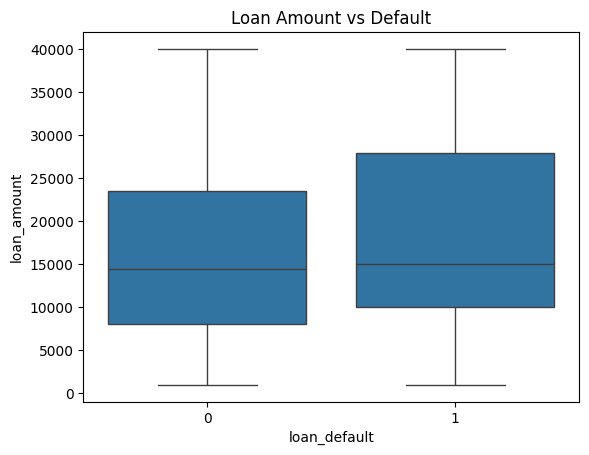

In [11]:
sns.boxplot(
    data=df,
    x='loan_default',
    y='loan_amount'
)
plt.title('Loan Amount vs Default')
plt.show()

In [12]:
grade_default=pd.crosstab(
    df['grade'],
    df['loan_default'],
    normalize='index'
)*100
grade_default

loan_default,0,1
grade,,
A,99.227328,0.772672
B,98.913401,1.086599
C,98.039955,1.960045
D,96.611342,3.388658
E,94.925373,5.074627
F,87.931034,12.068966
G,91.666667,8.333333


<function matplotlib.pyplot.show(close=None, block=None)>

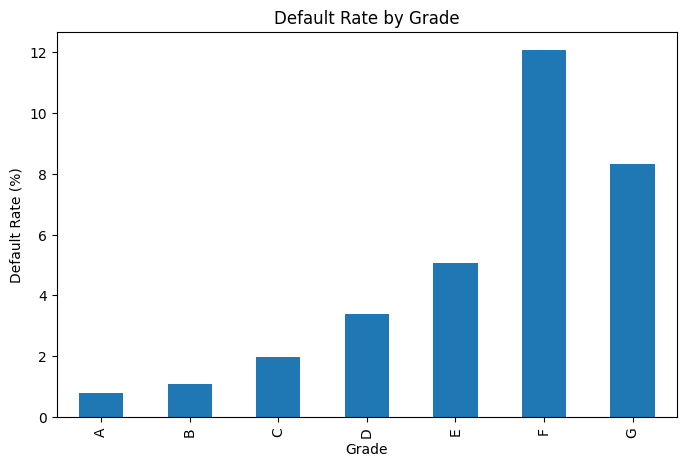

In [13]:
grade_default[1].plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Default Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Default Rate (%)')
plt.show

In [14]:
purpose_default=pd.crosstab(
    df['loan_purpose'],
    df['loan_default'],
    normalize='index'
)*100
purpose_default.sort_values(
    by=1,
    ascending=False
)

loan_default,0,1
loan_purpose,,
house,93.377483,6.622517
medical,96.296296,3.703704
car,96.946565,3.053435
major_purchase,97.029703,2.970297
moving,97.101449,2.898551
home_improvement,97.794118,2.205882
other,98.140044,1.859956
debt_consolidation,98.289269,1.710731
vacation,98.387097,1.612903


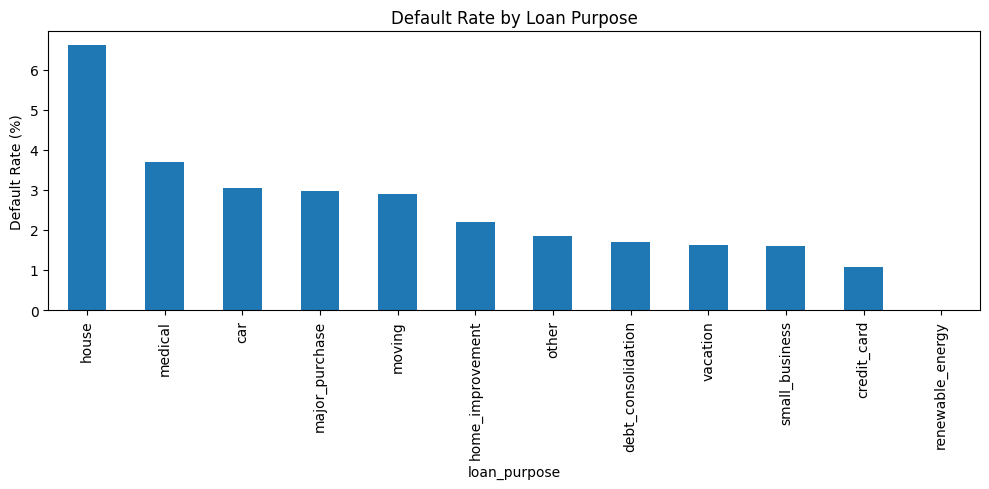

In [18]:
purpose_default[1].sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5),
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.title('Default Rate by Loan Purpose')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

In [16]:
pd.crosstab(
    df['homeownership'],
    df['loan_default'],
    normalize='index'
).round(4) * 100

loan_default,0,1
homeownership,,
MORTGAGE,98.58,1.42
OWN,97.49,2.51
RENT,98.03,1.97


In [19]:
df['homeownership'].value_counts()

homeownership
MORTGAGE    4789
RENT        3858
OWN         1353
Name: count, dtype: int64

In [17]:
pd.crosstab(
    df['term'],
    df['loan_default'],
    normalize='index'
).round(4) * 100

loan_default,0,1
term,,
36,98.45,1.55
60,97.69,2.31


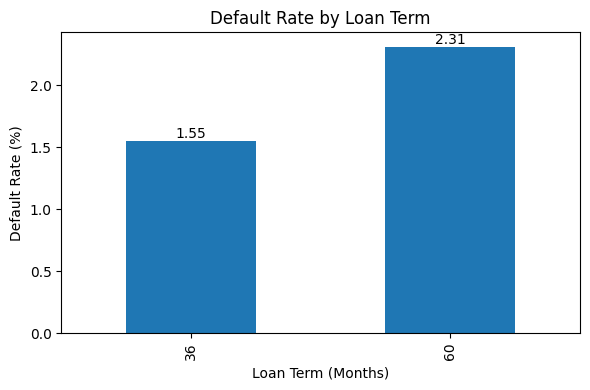

In [21]:
term_default=pd.crosstab(
    df['term'],
    df['loan_default'],
    normalize='index'
)*100
ax=term_default[1].plot(
    kind='bar',
    figsize=(6,4)
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.title('Default Rate by Loan Term')
plt.ylabel('Default Rate (%)')
plt.xlabel('Loan Term (Months)')
plt.tight_layout()
plt.show()

In [22]:
state_default=pd.crosstab(
    df['state'],
    df['loan_default'],
    normalize='index'
)*100
state_default.sort_values(
    by=1,
    ascending=False
).head(10)

loan_default,0,1
state,,
DE,91.666667,8.333333
HI,94.285714,5.714286
AR,95.714286,4.285714
NC,96.321070,3.678930
NY,96.721311,3.278689
NV,96.835443,3.164557
MS,97.222222,2.777778
MA,97.468354,2.531646
OK,97.530864,2.469136


In [23]:
df['state'].value_counts().loc[
    ['DE','HI','AR','NC','NY','NV','MS','MA','OK','NM']
]

state
DE     24
HI     35
AR     70
NC    299
NY    793
NV    158
MS     72
MA    237
OK     81
NM     43
Name: count, dtype: int64

In [25]:
state_summary=pd.DataFrame({
    'Loans': df.groupby('state').size(),
    'Default_Rate':df.groupby('state')['loan_default'].mean()*100
})
state_summary=state_summary[
    state_summary['Loans'] >= 100
]
state_summary.sort_values(
    by='Default_Rate',
    ascending=False
).head(10)

,Loans,Default_Rate
state,,
NC,299,3.678930
NY,793,3.278689
NV,158,3.164557
MA,237,2.531646
IN,178,2.247191
OH,338,2.071006
FL,732,2.049180
CA,1330,1.804511
NJ,338,1.775148


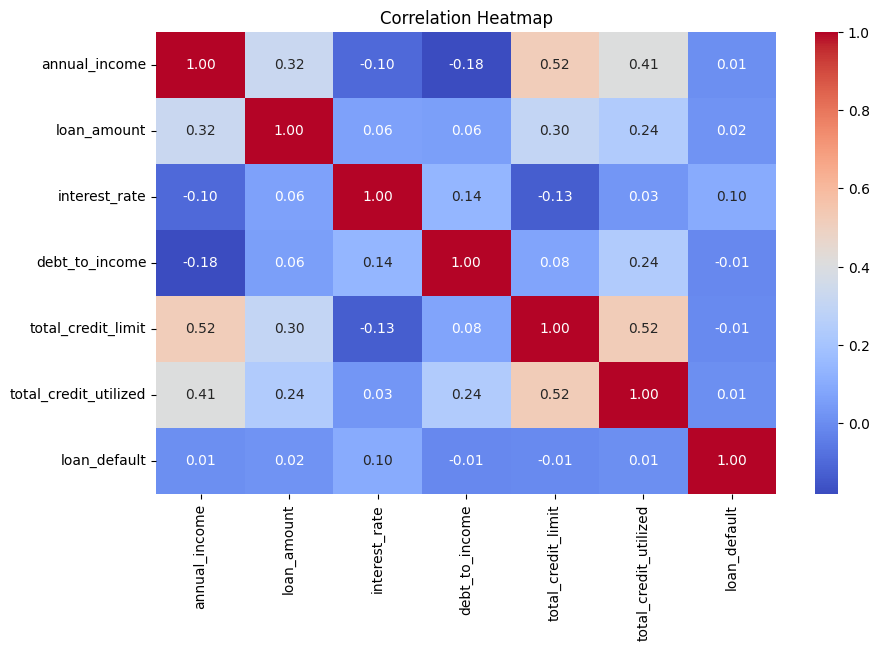

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols=[
    'annual_income',
    'loan_amount',
    'interest_rate',
    'debt_to_income',
    'total_credit_limit',
    'total_credit_utilized',
    'loan_default'
]
plt.figure(figsize=(10,6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

# key findings

## Key Findings

### High-Risk Characteristics

- Grade F loans exhibited the highest default rate at 12.07%, compared to only 0.77% for Grade A loans.
- House loans showed the highest default rate among loan purposes (6.62%), followed by medical loans (3.70%).
- Borrowers with 60-month loan terms had a higher default rate (2.31%) than those with 36-month terms (1.55%).
- Defaulted borrowers had a higher average interest rate (16.10%) than non-defaulted borrowers (12.36%).

### Lower-Risk Characteristics

- Grade A loans demonstrated the lowest default rate (0.77%).
- Credit card loans showed one of the lowest default rates (1.07%).
- Borrowers with 36-month loan terms were less likely to default compared to those with longer loan durations.

### Geographic Insights

Among states with at least 100 loans, North Carolina (3.68%), New York (3.28%), and Nevada (3.16%) exhibited the highest default rates.

### Overall Conclusion

Loan grade, interest rate, loan purpose, and loan term emerged as the most important indicators of default risk. These findings can help financial institutions identify higher-risk borrowers and improve lending decisions.